In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np 
import seaborn as sns 
import folium
from datetime import datetime, timedelta

import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go

In this project, we take a closer look at the UNHCR dataset on Displacements. This dataset is a comprehensive list that records international desplacements from 1962 to 2025, where each entry has a country of "Origin", "Arrival" and a number of people. We have over 100.000 entries to look work with. Let's have a first look.

# 1 - Prepping the Data

In [27]:
# load excel dataset
raw_data = pd.read_excel(
    '/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/UNHCR_Flow_Data.xlsx',
    sheet_name='DATA'
)

print(raw_data.shape)
raw_data[:10]

(107341, 10)


,origin,OriginISO,OriginName,asylum,AsylumISO,AsylumName,AsylumRegion,Population types,Year,Count
0,ALG,DZA,Algeria,MTA,MLT,Malta,Europe,REF,1962,5
1,ANG,AGO,Angola,COD,COD,Dem. Rep. of the Congo,West and Central Africa,REF,1962,20000
2,ANG,AGO,Angola,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,277
3,BDI,BDI,Burundi,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,13
4,CHI,CHN,China,NEP,NPL,Nepal,Asia and the Pacific,REF,1962,5
5,COB,COG,"Congo, Republic of",NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,8
6,COD,COD,Dem. Rep. of the Congo,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,13
7,IRQ,IRQ,Iraq,MTA,MLT,Malta,Europe,REF,1962,17
8,SOM,SOM,Somalia,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,5
9,SUD,SDN,Sudan,MTA,MLT,Malta,Europe,REF,1962,10


### 1.1 - Data Cleaning

Though the initial data looks rather clean to start with, we found a few duplicates, removed missung values and cleaned it a bit furthe for ease of use.

In [28]:
# -------------------------------------------------------------------
#                      changes to the raw data 
# -------------------------------------------------------------------

#    lower casing
# ------------------
# header to lowercase
raw_data.columns = raw_data.columns.str.lower()
# data to lowercase
for col in raw_data.select_dtypes(include='object'):
    raw_data[col] = raw_data[col].str.lower()

# check for duplicates
# ---------------------
print("number of duplicates found:", raw_data.duplicated().sum())
# remove duplicates
raw_data = raw_data.drop_duplicates()

# check for missing values
# ---------------------
print(raw_data.isnull().sum()) 
# remove rows with missing values
raw_data = raw_data.dropna()


# -------------------------------------------------------------------

# Sanity check it worked:
# ---------------------
# print(raw_data.isnull().sum())
raw_data[:5]


number of duplicates found: 0
origin               0
originiso            0
originname          35
asylum               0
asylumiso            0
asylumname           0
asylumregion        37
population types     0
year                 0
count                0
dtype: int64


,origin,originiso,originname,asylum,asylumiso,asylumname,asylumregion,population types,year,count
0,alg,dza,algeria,mta,mlt,malta,europe,ref,1962,5
1,ang,ago,angola,cod,cod,dem. rep. of the congo,west and central africa,ref,1962,20000
2,ang,ago,angola,nam,nam,namibia,eastern and southern africa,ref,1962,277
3,bdi,bdi,burundi,nam,nam,namibia,eastern and southern africa,ref,1962,13
4,chi,chn,china,nep,npl,nepal,asia and the pacific,ref,1962,5


In [29]:
# ---------------------------------------------------------
#         Dealing with long impractical country names
# ---------------------------------------------------------

# change "originname"
name_edits = {
    "serbia and kosovo: s/res/1244 (1999)": "serbia/kosovo",
    "bolivia (plurinational state of)": "bolivia",
    "iran (islamic rep. of)": "iran",
    "netherlands (kingdom of the)": "nederland",
    "côte d'ivoire": "ivory coast",
    "state of palestine": "palestine",
    "lao people's dem. rep": "laos",
    "russian federation": "russia",
    "syrian arab rep.": "syria",
    "dem. rep. of the congo": "dr congo",
    "congo, republic of": "congo",
    "china, hong kong sar": "hong kong",
    "rep. of korea": "south korea",
    "dem. people's rep. of korea": "north korea",
    "central african rep.": "central african republic",
    "dominican rep.": "dominican republic",
    "united rep. of tanzania": "tanzania",
    "venezuela (bolivarian republic of)": "venezuela",
    "rep. of moldova": "moldova"
}

# count number of "serbia and kosovo: s/res/1244 (1999)" entries
print("number of 'serbia and kosovo: s/res/1244 (1999)' entries:", raw_data[raw_data['originname'] == "serbia and kosovo: s/res/1244 (1999)"].shape[0])
# count number of "côte d'ivoire" entries
print("number of 'côte d'ivoire' entries:", raw_data[raw_data['originname'] == "côte d'ivoire"].shape[0])
print()


#            Apply changes
# -----------------------------------
# country name changes to the 'originname' column
raw_data['originname'] = raw_data['originname'].replace(name_edits)

# sanity check it worked
print("number of 'serbia/kosovo' entries after edit:", raw_data[raw_data['originname'] == "serbia/kosovo"].shape[0])
# number of "ivory coast" entries after edit
print("number of 'ivory coast' entries after edit:", raw_data[raw_data['originname'] == "ivory coast"].shape[0])


number of 'serbia and kosovo: s/res/1244 (1999)' entries: 1145
number of 'côte d'ivoire' entries: 1348

number of 'serbia/kosovo' entries after edit: 1145
number of 'ivory coast' entries after edit: 1348


### 1.2 - Exporting Cleaned Data

In [30]:
# --------------------------------------------------------------
#             Export cleaned Data ----> CSV format
# --------------------------------------------------------------

clean_data = raw_data.copy()

# export cleaned data to csv
clean_data.to_csv('/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/cleaned_data.csv', index=False)

### 1.3 - Filtering 

Since the focus of our story, will be on major events in recent history we decided to apply a filter to the cleaned data, only to keep entries that recod 100 people or more. Initial analysis reveal that a great majority, i.e. over 76000 entries record "minor" numbers or displaced people. We filtered those out for our story but alsp kept the complete cleaned dataset for later use and comparaison.

In [31]:
# -----------------------------------------------------------------
#                            filters 
# -----------------------------------------------------------------

#       Less than 100
# ----------------------------
# Count rows that have 'count' less than 100
less_than_100 = raw_data[raw_data['count'] < 100].shape[0]
print(f"Number of rows with 'count' less than 100: {less_than_100}")
# filter out rows where 'count' is less than 100
filtered_data = raw_data[raw_data['count'] >= 100].copy()


Number of rows with 'count' less than 100: 76864


In [32]:
# --------------------------------------------------------------
#            Export filtered Data ----> CSV format
# --------------------------------------------------------------

filtered_data = filtered_data.copy()
# export filtered data to csv
filtered_data.to_csv('/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Data/filtered_data.csv', index=False)

# 2 - A First Look 

Now that the data is cleaned, we can dive in and have a first look. 

How many datapoints do we have each year? is it a comparable amount? 

### 1.1 - Number of entries per year

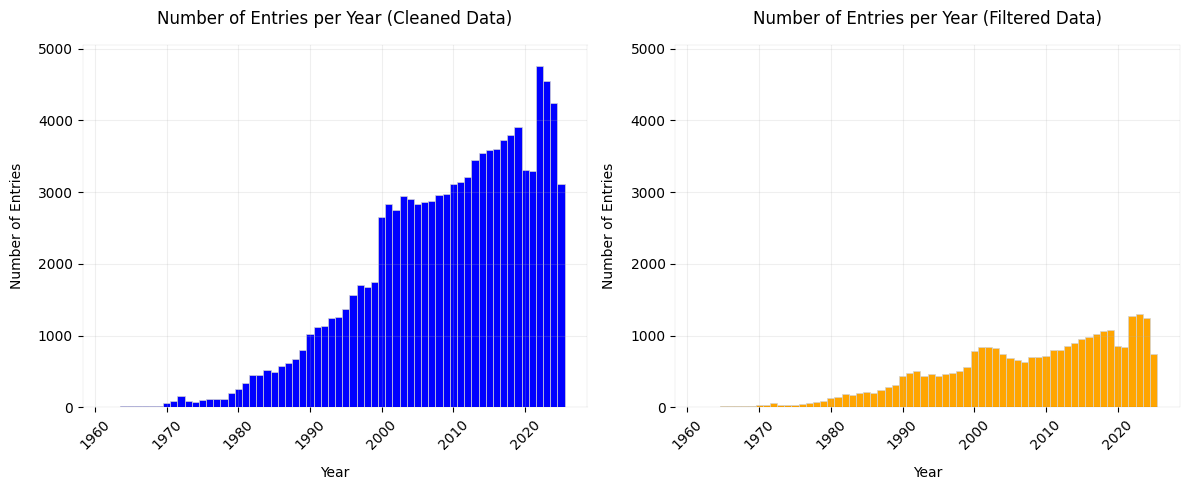

In [ ]:
# ---------------------------------------------------------------
#                           data count 
# ---------------------------------------------------------------

# count number of entries per year for the cleaned data
num_entries_per_year_clean = clean_data['year'].value_counts().sort_index()
# print(num_entries_per_year_clean)

# count number of entries per year for filtered data
num_entries_per_year_filtered = filtered_data['year'].value_counts().sort_index()
# print(num_entries_per_year_filtered)

# common y-axis limit
max_count = max(
    num_entries_per_year_clean.max(),
    num_entries_per_year_filtered.max()
)

# plot the two histograms side by side
# -------------------------------------
plt.figure(figsize=(12, 5))

#           cleaned data
# -------------------------------------
plt.subplot(1, 2, 1)
plt.hist(
    clean_data['year'],
    bins=np.arange(
        clean_data['year'].min(),
        clean_data['year'].max() + 2
    ) - 0.5,
    color='blue',
    edgecolor='lightgray',
    linewidth=0.5
)

plt.title('Number of Entries per Year (Cleaned Data)', pad=15, fontsize=12)
plt.xlabel('Year', labelpad=10)
plt.ylabel('Number of Entries', labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, max_count + 300)
plt.margins(y=0.05)
plt.grid(axis='x', alpha=0.2)
plt.grid(axis='y', alpha=0.2)


#           filtered data
# -------------------------------------
plt.subplot(1, 2, 2)
plt.hist(
    filtered_data['year'],
    bins=np.arange(
        filtered_data['year'].min(),
        filtered_data['year'].max() + 2
    ) - 0.5,
    color='orange',
    edgecolor='lightgray',
    linewidth=0.5
)

plt.title('Number of Entries per Year (Filtered Data)', pad=15, fontsize=12)
plt.xlabel('Year', labelpad=10)
plt.ylabel('Number of Entries', labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, max_count + 300)
plt.margins(y=0.05)
plt.grid(axis='x', alpha=0.2)
plt.grid(axis='y', alpha=0.2)

# change opacity of the frame
for ax in plt.gcf().axes:
    for spine in ax.spines.values():
        spine.set_edgecolor((0, 0, 0, 0.2))  # 20% opacity
        spine.set_linewidth(0.2)

plt.tight_layout()

plt.show()



Here's a closer look at entries between 1962 and 1981, since some of those values are relatively low

In [ ]:
# first 10 years
clean_first_20 = num_entries_per_year_clean.head(20)
filtered_first_20 = num_entries_per_year_filtered.head(20)

# create comparison table
comparison_table = pd.DataFrame({
    'Cleaned Data': clean_first_20,
    'Filtered Data': filtered_first_20
}).T

print(comparison_table)

year           1962  1963  1964  1965  1966  1967  1968  1969  1970  1971  \
Cleaned Data     10     8    14    19    25    20    21    22    63    95   
Filtered Data     2     7    13    18    22    16    19    18    32    35   

year           1972  1973  1974  1975  1976  1977  1978  1979  1980  1981  
Cleaned Data    161    89    75   100   124   116   123   198   255   337  
Filtered Data    57    37    38    37    55    60    74    93   134   142  


### 1.2 - A closer look at the countries

How many total countries are mentioned in this dataset? When are they first mentionned? Can we see some new counrty names appearing over time? for example: Croatia, Estonia, Slovenia, Kazakhstan, Azerbaijan in the early 90's? Eritrea in 1993? Montenegro/Serbia 2006? South Sudan in 2011? 

Are there countries that only "recieve" asylum seekers? 
Are there countries that only "send" asylunm seekers?

In [ ]:

#---------------------------------
#    unique ORIGIN countries
#---------------------------------
# total names and year
unique_origin_countries = clean_data['originname'].unique()
print("Total unique origin countries:", len(unique_origin_countries))

# year of the first and last mention of each country in the origin column
first_mention_origin_country = clean_data.groupby('originname')['year'].min()
last_mention_origin_country = clean_data.groupby('originname')['year'].max()

#---------------------------------
#   unique DESTINATION countries
#---------------------------------
# total name and year
unique_destination_countries = clean_data['asylumname'].unique()
print("Total unique destination countries:", len(unique_destination_countries))

# year of the first and last mention of each country in the destination column
first_mention_destination_country = clean_data.groupby('asylumname')['year'].min()
last_mention_destination_country = clean_data.groupby('asylumname')['year'].max()

#---------------------------------
#  COMBINED: unique country names
#---------------------------------
unique_countries = set(unique_origin_countries).union(set(unique_destination_countries))
print("Total unique countries (origin + destination):", len(unique_countries))
print()
print("print 10 frist unique countries:", list(unique_countries)[:10]) # print first 10 unique countries (origin + destination)

# find the 3 countries that are only in the destination column and not in the origin column
only_destination_countries = set(unique_destination_countries) - set(unique_origin_countries)
print("Countries that are only in the destination column", only_destination_countries)

# ---------------------------------
#          World Regions
# ---------------------------------
# region of each unique countries
region_unique_countries = clean_data.groupby('asylumname')['asylumregion'].first().to_dict()


#---------------------------------
#        COMBINED dataframe
#---------------------------------
first_mention_country = pd.concat([
    first_mention_origin_country,
    first_mention_destination_country
], axis=1).min(axis=1)

last_mention_country = pd.concat([
    last_mention_origin_country,
    last_mention_destination_country
], axis=1).max(axis=1)

# combine first and last year into one dataframe
country_years = pd.DataFrame({
    'country': first_mention_country.index,
    'start': first_mention_country.values,
    'end': last_mention_country.values
})


#---------------------------------
#        regroup per region
#---------------------------------

# add region column to the country_years dataframe
country_years['region'] = country_years['country'].map(region_unique_countries)
# number or regions
print("Number of unique regions:", country_years['region'].nunique())
print("Unique regions:", country_years['region'].unique())
# find input with Nan
print("Countries with missing region:", country_years[country_years['region'].isna()]['country'].tolist())
# sort by regions
country_years = country_years.sort_values(by='region')


country_years_by_region = {
    region: df.reset_index(drop=True)
    for region, df in country_years.groupby('region')
}

region_colors = {
    'europe': 'blue',
    'middle east and north africa': 'red',
    'asia and the pacific': 'green',
    'eastern and southern africa': 'orange',
    'americas': 'purple',
    'west and central africa': 'brown'
}


Total unique origin countries: 213
Total unique destination countries: 189
Total unique countries (origin + destination): 232

print 10 frist unique countries: ['zambia', 'türkiye', 'central african republic', 'armenia', 'pakistan', 'uganda', 'finland', 'syrian arab rep.', 'morocco', 'sao tome and principe']
Countries that are only in the destination column {'rep. of korea', 'russian federation', 'british virgin islands', 'syrian arab rep.', 'aruba', 'rep. of moldova', 'congo, republic of', 'dominican rep.', 'venezuela (bolivarian republic of)', 'netherlands (kingdom of the)', "côte d'ivoire", 'iran (islamic rep. of)', 'dem. rep. of the congo', 'united rep. of tanzania', 'central african rep.', 'serbia and kosovo: s/res/1244 (1999)', 'china, hong kong sar', 'sint maarten (dutch part)', 'bolivia (plurinational state of)'}
Number of unique regions: 6
Unique regions: ['asia and the pacific' 'europe' 'middle east and north africa' nan
 'eastern and southern africa' 'americas' 'west and cen

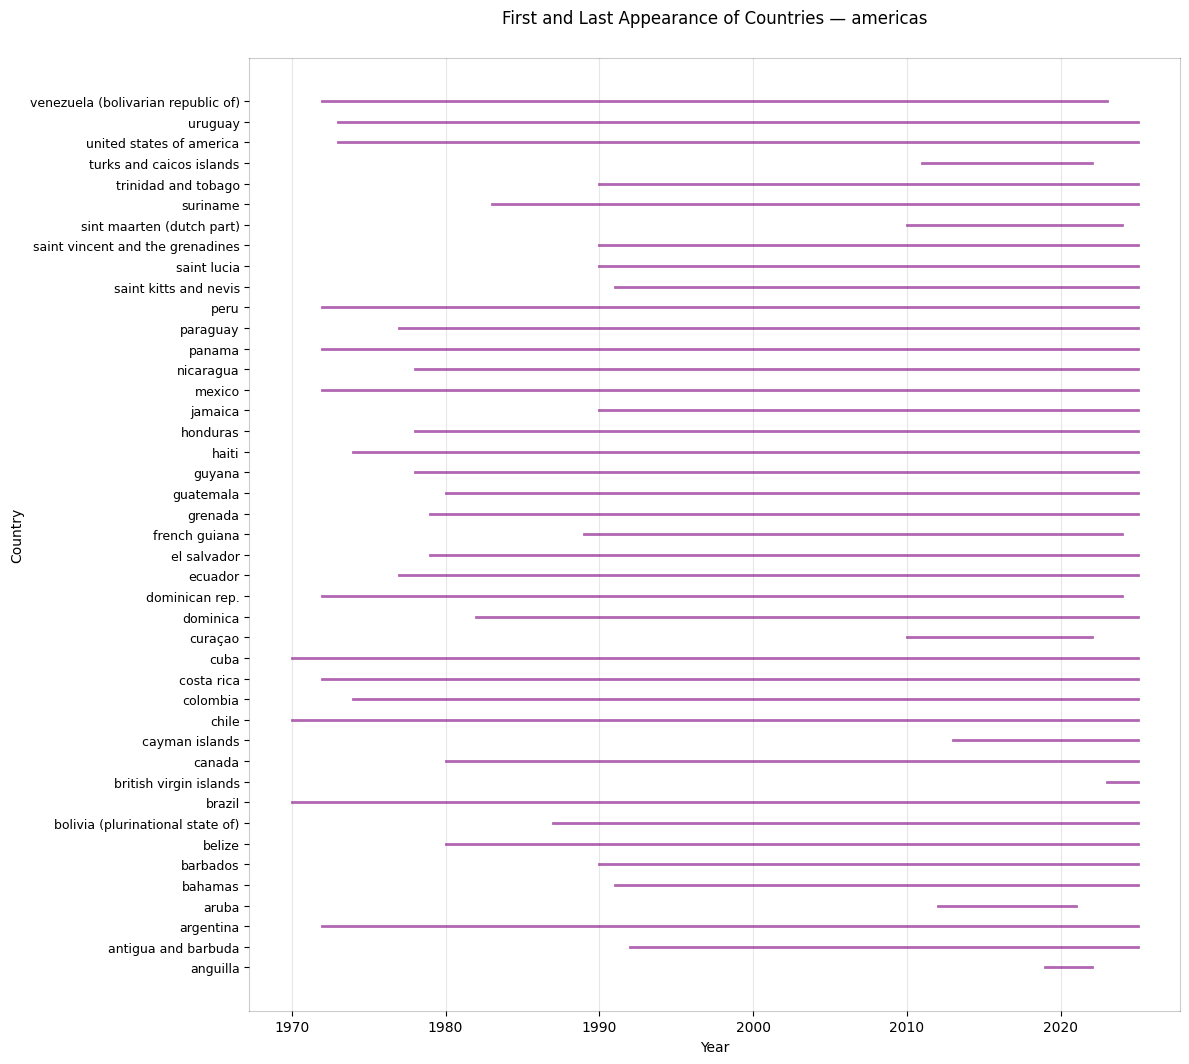

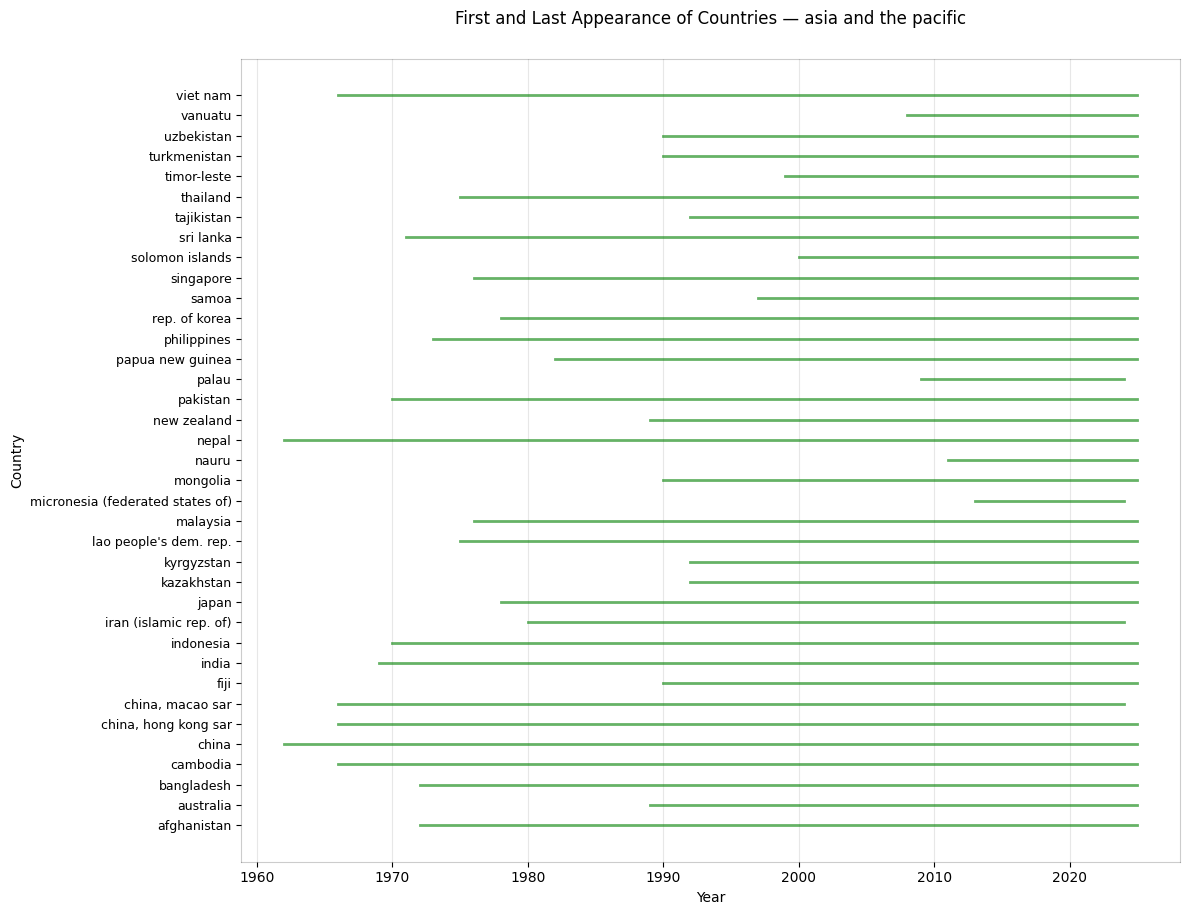

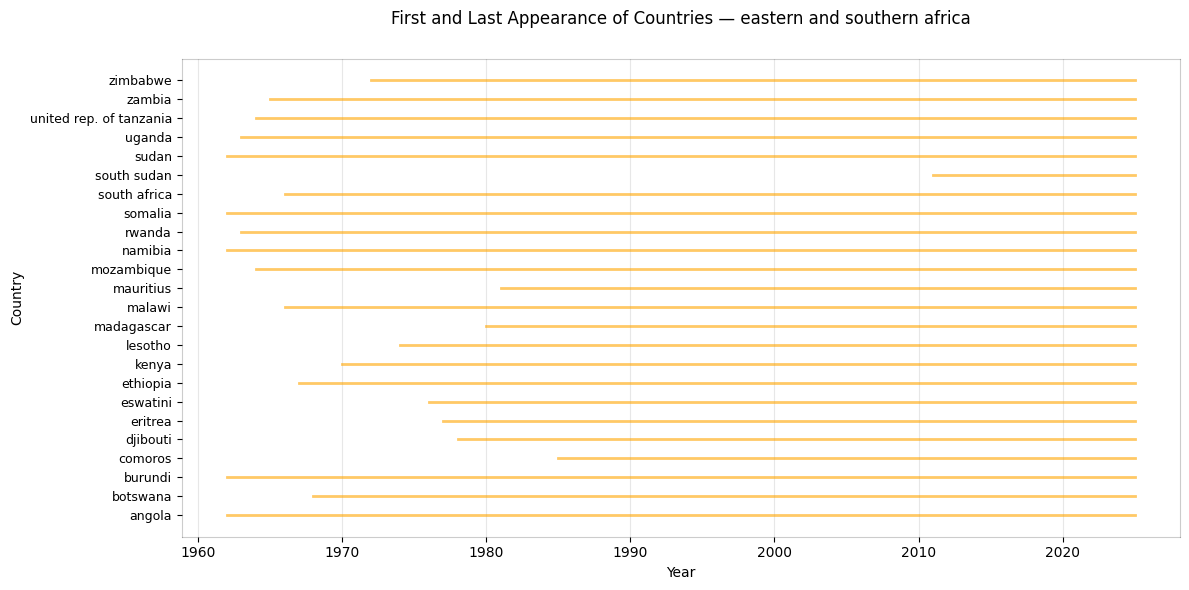

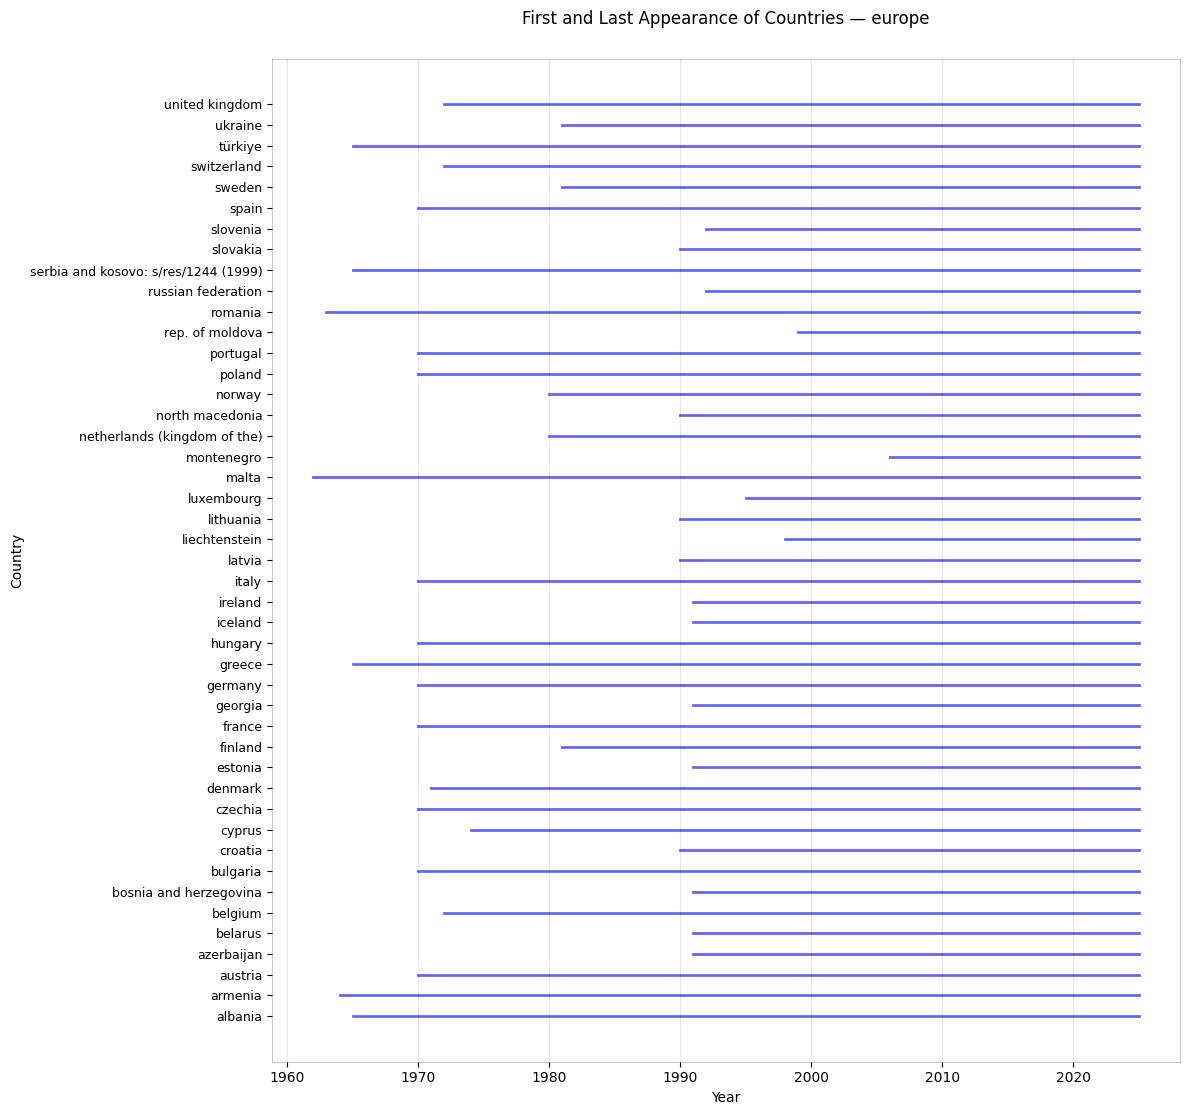

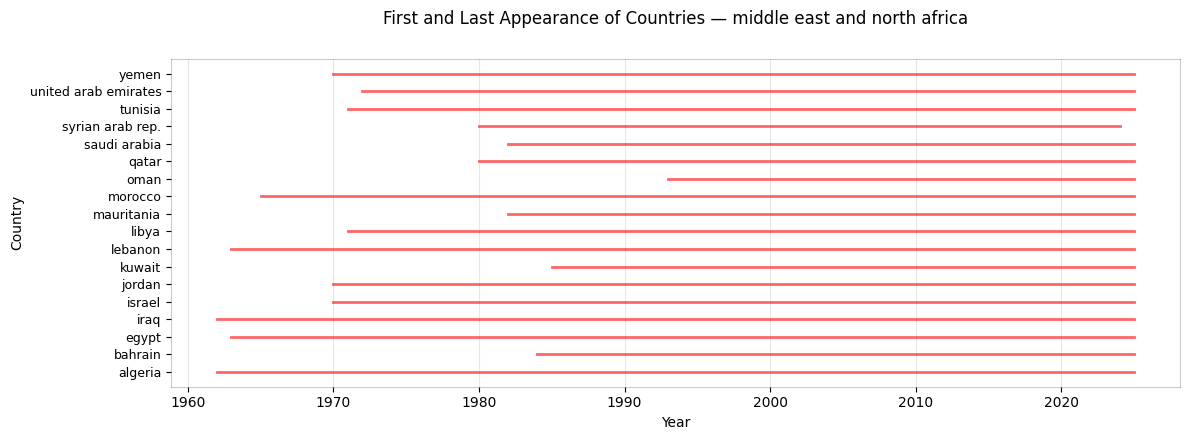

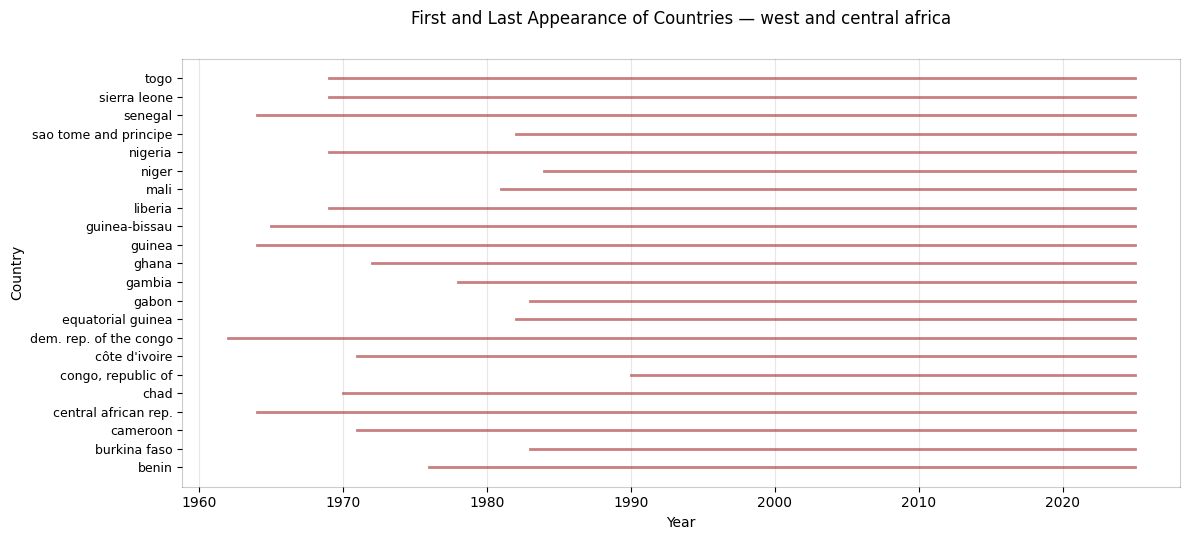

In [ ]:
# split into different dataframes by region
country_years_by_region = {
    region: df.reset_index(drop=True)
    for region, df in country_years.groupby('region')
}

region_colors = {
    'europe': 'blue',
    'middle east and north africa': 'red',
    'asia and the pacific': 'green',
    'eastern and southern africa': 'orange',
    'americas': 'purple',
    'west and central africa': 'brown'
}

#---------------------------------
#        LOOP OVER REGIONS
#---------------------------------
for region, df_region in country_years.groupby('region'):

    df_region = df_region.sort_values(by='country').reset_index(drop=True)

    n = len(df_region)
    plt.figure(figsize=(12, n * 0.25))

    for i, row in df_region.iterrows():
        plt.plot(
            [row['start'], row['end']],
            [i, i],
            region_colors.get(region, 'grey'),
            alpha=0.6,
            linewidth=2
        )

    plt.yticks(range(len(df_region)), df_region['country'], fontsize=9)
    plt.xlabel('Year')
    plt.ylabel('Country')
    plt.title(f'First and Last Appearance of Countries — {region}', pad=25)

    # frame opacity
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_alpha(0.2)

    plt.margins(y=0.05)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    # save plots
    plt.savefig(f'/Users/tish/Documents/Flexible Masters/02806 - Social data and visualization/CODE_Social_data_Visialization/TishDuc.github.io/Displacements_Final_Project/Graphs and visualizations/first_last_country_apearance_{region}.png', dpi=300)

    plt.show()

# Draft

In [ ]:
# -----------------------------------------------------------------
#                       Things to talk about ? 
# -----------------------------------------------------------------

"""

 EXPLORATION OF THE DATA 
            <br>
            whata re the top 3 events in our data that caused the largest displacements?
            <br>
            (this is a good spot for Loke's chart).
            0 - filtering: only keep "significant" displacements, removeless than 100 people entries +  displacement from 10.000 people per year = min threshold, 
            or use median if number of displaced is larger than 10K
            <br>
            2 - in sheer numbers ...what are the largest displacements recorded in our data 
            3 - taking into consideration the length of the conflict/crisis. 1 million people moving over 20 years doesn't have the same impart as 
            1 million people moving over 1 year. so we can compute a "ratio" of "total displaced" VS "annual displaced"
            <img src="TishDuc.github.io/Displacements_Final_Project/Draft/Top_10.png"/>
            <p class="caption">
            Top 10 events in the modern era that caused the largest displacements. Computed taking into consideration the length of the crisis, 
            to show the "intensity" of the displacements.
            </p>
            <br>
            OUR DATA: UNHCR data on displacements around the world, from 1962 to 2025 + other data GDP? country population (to compute ratios)? 
        </p>
        </section>


        </section>
        <section class = "text"></section>

        DRAFT OF THE STORY:
            <br>
            <br>
            - Ratio thing: Natural disasters/conflicts/war have different lengths. find a way to express the "amount" of displcement 
            taking that into consideration. 1 million people moving over 20 years doesn't have the same impart as 
            1 million people moving over 1 year. 
            Total displaced VS annual displaced
            <br>
            <br>
            - Filtering the data: 
            crisis = 10.000 peple displaced in 1 year - OR - use a "percentage/median" of the total population of the country (example of Afghanistan)
            removed "tiny" values, only kept movements of more than 100 people 
            <br>
            <br>
            - Sometimes, lots of poeple move from A to B (single country), other times people move from B to B, C, D,..(several countries)
            why? is this something to look into?
            <br>
            <br>
            - Early data: Some large conflicts from the 70's80's (Afganistan/Ethiopia) make it in out "Top" 20 in sheer number of displaced.
            Yet data of that period is so sparce/so rare at the time. Does that mean that the actual number of displaced was HUUUUUGE?
            <br>
            <br>
            - Displacements types: Asylum seekers, refugees....
            Do we look into the different status of displaced people? 
            <br>
            <br>
            - Suspiciously round numbers: in the data ... were there exactly 20,000 people moving from Angola to Congo in 1962?
            looks suspicious to me?
            <br>
            <br>
            - Why do they "choose" the country the go to? 
            is it because of language? culture/religoin? proximity? economic opportunities? easier migration policies?
            <br>
            <br>
            LIMITS OF OUR DATASET: 
            <br>
            <br>
            - Only tracks INTERNATIONAL movements... so it' snot adequate for "natural disasters", or local population movements
            not adequete for tsunami in 2006 in indonesia: too many different countries around the Indian Ocean.
            partly Adequate for Tchernobyl in 1986?...ish (people moving from Ukraine to Russia)? but not tracting russian people moving elsewhere to Russia.
            <br>
            <br>
            - Displacements are recorded per year: so we can-t look at the "immediate" impact of a crisis, but rather the "long-term" impact. 
            and we can't look at super short yet intense crisis.
            <br>
            <br>
            limited data from 1960 to ...1990...2000
            <br>
            <br>
            Keeping in mind the numbers we have are only the "ocfficially" recorded displacements... there are probably many more.
            <br>
            <br>
            - "unknown" or "stateless" displacements: 
            Do we count "unkown" as missing data?
            Or are they called "unknown" because origin countries were renamed/created/disappeared OR are those the precisely 
            the "stateless" entries? foe example we soo lots of "stateless" displacements entering Europe in 1989... ex-Yougoslavia?
            In some cases (Uganda) it be that people they wish to remain unknown for their own safety...for political/ethnicity/religious reasons 
         
            

"""

'\n\n EXPLORATION OF THE DATA \n            <br>\n            whata re the top 3 events in our data that caused the largest displacements?\n            <br>\n            (this is a good spot for Loke\'s chart).\n            0 - filtering: only keep "significant" displacements, removeless than 100 people entries +  displacement from 10.000 people per year = min threshold, \n            or use median if number of displaced is larger than 10K\n            <br>\n            2 - in sheer numbers ...what are the largest displacements recorded in our data \n            3 - taking into consideration the length of the conflict/crisis. 1 million people moving over 20 years doesn\'t have the same impart as \n            1 million people moving over 1 year. so we can compute a "ratio" of "total displaced" VS "annual displaced"\n            <img src="TishDuc.github.io/Displacements_Final_Project/Draft/Top_10.png"/>\n            <p class="caption">\n            Top 10 events in the modern era that c